In [1]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import (
    Dense, Conv2D, MaxPooling2D, Dropout,
    GlobalAveragePooling2D, BatchNormalization, ReLU
)
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# ==========================================
# 2️⃣ DATASET LOADING & PREPROCESSING
# ==========================================

dataset_path = "money"
IMG_SIZE = 128  # Faster and balanced (you can use 128 if accuracy needed)

images = []
classno = []

classes = os.listdir(dataset_path)

for idx, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)

    if os.path.isdir(folder):
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)

            if img is not None:

                # Convert BGR to RGB (better for CNN)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Noise Reduction (Edge Preserving)
               # img = cv2.bilateralFilter(img, 9, 75, 75)

                # Sharpening
               # kernel = np.array([[0, -1, 0],
                #                 [-1, 5, -1],
                 #                 [0, -1, 0]])
                #img = cv2.filter2D(img, -1, kernel)

                # Normalize (Rule)
                img = img / 255.0

                images.append(img)
                classno.append(idx)

images = np.array(images, dtype=np.float32)
classno = np.array(classno)

print("Total Images:", len(images))
print("Shape:", images.shape)

Total Images: 18000
Shape: (18000, 128, 128, 3)


In [3]:
images

array([[[[0.75686276, 0.75686276, 0.8039216 ],
         [0.75686276, 0.75686276, 0.8039216 ],
         [0.7607843 , 0.7607843 , 0.80784315],
         ...,
         [0.6901961 , 0.7058824 , 0.7176471 ],
         [0.69803923, 0.7137255 , 0.7254902 ],
         [0.69803923, 0.7137255 , 0.7254902 ]],

        [[0.75686276, 0.75686276, 0.8039216 ],
         [0.75686276, 0.75686276, 0.8039216 ],
         [0.75686276, 0.75686276, 0.8039216 ],
         ...,
         [0.69803923, 0.7137255 , 0.7254902 ],
         [0.69803923, 0.7137255 , 0.7254902 ],
         [0.69803923, 0.7137255 , 0.7254902 ]],

        [[0.7647059 , 0.7647059 , 0.8117647 ],
         [0.75686276, 0.75686276, 0.8039216 ],
         [0.75686276, 0.75686276, 0.8039216 ],
         ...,
         [0.6901961 , 0.7058824 , 0.7176471 ],
         [0.6901961 , 0.7058824 , 0.7176471 ],
         [0.69803923, 0.7137255 , 0.7254902 ]],

        ...,

        [[0.77254903, 0.78431374, 0.8117647 ],
         [0.7647059 , 0.7764706 , 0.8039216 ]

In [4]:
classno

array([0, 0, 0, ..., 5, 5, 5], shape=(18000,))

In [6]:
# ==========================================
# 3️⃣ DATA SPLIT (TRAIN / VAL / TEST)
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    images, classno,
    test_size=0.1,
    random_state=42
)



In [7]:
print(np.unique(y_train))

[0 1 2 3 4 5]


In [8]:
num_classes = 6
IMG_SIZE = 128  # or your size

model2 = Sequential()

# BLOCK 1
model2.add(Conv2D(32, (3,3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(MaxPooling2D((2,2)))

# BLOCK 2
model2.add(Conv2D(64, (3,3), padding='same'))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(MaxPooling2D((2,2)))

# BLOCK 3
model2.add(Conv2D(128, (3,3), padding='same'))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(Conv2D(128, (3,3), padding='same'))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(MaxPooling2D((2,2)))

# GLOBAL POOLING (GOOD)
model2.add(GlobalAveragePooling2D())

# CLASSIFIER
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.3))  # reduced dropout

model2.add(Dense(num_classes, activation='softmax'))

model2.summary()

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 306,086 (1.17 MB)

 Trainable params: 305,190 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
from keras.optimizers import Adam

model2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model2.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=32,
    callbacks=[early]
)

Epoch 1/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 225s 437ms/step - accuracy: 0.9688 - loss: 0.1704 - val_accuracy: 0.9494 - val_loss: 0.2588
Epoch 2/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 215s 423ms/step - accuracy: 0.9996 - loss: 0.0183 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 3/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 216s 427ms/step - accuracy: 0.9999 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 0.0096
Epoch 4/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 214s 423ms/step - accuracy: 0.9989 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 5/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 216s 425ms/step - accuracy: 0.9999 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 0.0092


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model2.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# y_test is already class index (not one-hot)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# Classification Report
print(classification_report(y_true, y_pred_classes))

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step
[[288   0   0   0   0   0]
 [  0 296   0   0   0   0]
 [  0   0 322   0   0   0]
 [  0   0   0 299   0   0]
 [  0   0   0   0 292   0]
 [  0   0   0   0   0 303]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       288
           1       1.00      1.00      1.00       296
           2       1.00      1.00      1.00       322
           3       1.00      1.00      1.00       299
           4       1.00      1.00      1.00       292
           5       1.00      1.00      1.00       303

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



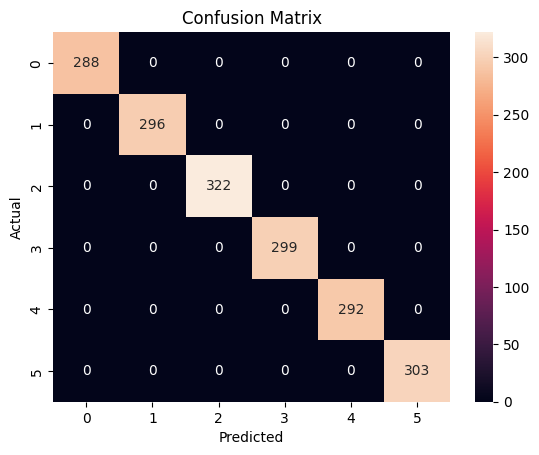

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
model2.save("money_model.h5")

In [ ]:
import cv2
import numpy as np
import os
from keras.models import load_model
import matplotlib.pyplot as plt

# ===============================
# 1️ LOAD MODEL
# ===============================
model = load_model("money_model.h5")

# ==============================
# 2 LOAD CLASS NAMES (SAFE WAY)
# ===============================
dataset_path = "money"
classes = sorted(os.listdir(dataset_path))
print("Classes:", classes)

IMG_SIZE = 128
CONFIDENCE_THRESHOLD = 0.70

# ===============================
# 3️ LOAD TEST IMAGE
# ===============================
image_path = "rupees-20-banknote-2020-inset-r-sign-shaktikant-das-555218-1.webp"   # change this to your image path

img = cv2.imread(image_path)

if img is None:
    print("Image not found!")
    exit()

# Keep original for display
original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ===============================
#  PREPROCESS (SAME AS TRAINING)
# ===============================
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0
img = np.expand_dims(img, axis=0)

# ===============================
#  PREDICTION
# ===============================
prediction = model.predict(img, verbose=0)
class_index = np.argmax(prediction)
confidence = np.max(prediction)

if confidence > CONFIDENCE_THRESHOLD:
    label = f"{classes[class_index]}  ({confidence*100:.2f}%)"
else:
    label = "Not confident"

print("Prediction:", label)

# ===============================
# 6️ SHOW RESULT
# ===============================
plt.imshow(original)
plt.title(label)
plt.axis("off")
plt.show()